In [2]:
import numpy as np
import pandas as pd
import os.path as op
import os
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

# in utils get_stress_level(): AUC per subject from ('/Users/mrenke/Desktop/StressRisk/2022-StressRisk/Data-Final/auc_cortisol.xlsx')


In [3]:
col_ofin_name = 'q_stress'
cols_ofin = [] # {}
for n in range(1,8):
    #d1[n] = col_ofin  + f'_{n}'
    cols_ofin.append(col_ofin_name  + f'_{n}')
#cols_ofin.append('condition')

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [4]:
df_comb = pd.read_excel('/Users/mrenke/Desktop/StressRisk/gokis_code/data_combined.xlsx')
df_comb = df_comb.rename(columns={'SUBID':'subject', 'condition':'group'}).set_index(['subject', 'group'])
df = df_comb[cols_ofin]
df.head()

,,q_stress_1,q_stress_2,q_stress_3,q_stress_4,q_stress_5,q_stress_6,q_stress_7
subject,group,,,,,,,
1,0,5,5,4,5,5,5,4
2,0,2,2,2,2,2,2,1
3,1,5,6,5,5,6,2,3
4,1,4,5,6,5,5,4,3
5,0,1,2,2,1,3,1,1


In [5]:
from sklearn import metrics

df['mean_stress'] = df.mean(axis=1)
df['min-max_diff'] = df.apply(lambda row: row[cols_ofin].max() - row[cols_ofin].min(), axis=1)
df['sd_stress'] = df.std(axis=1)
df['auc_stress'] = df.apply(lambda row: metrics.auc(range(1,8),row[cols_ofin]), axis=1) # not sure if this is doing it the way I want: metrics.auc(range(1,7), [10, 10, 10, 10, 10, 10])



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_74958/3637295616.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mean_stress'] = df.mean(axis=1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_74958/3637295616.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['min-max_diff'] = df.apply(lambda row: row[cols_ofin].max() - row[cols_ofin].min(), axis=1)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_74958/3637295616.py:5: SettingWithCopyWarning: 
A value is trying 

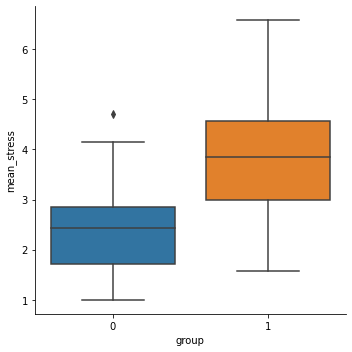

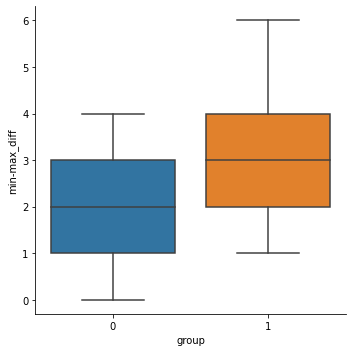

In [6]:
sns.catplot(data=df.reset_index(),y='mean_stress', x='group',kind='box')
sns.catplot(data=df.reset_index(),y='min-max_diff', x='group',kind='box')


In [8]:
# copied from analyse_results/utils.get_stress_level()

df_auc = pd.read_excel('/Users/mrenke/Desktop/StressRisk/2022-StressRisk/Data-Final/auc_cortisol.xlsx')
df_auc = df_auc.rename(columns={'SubjectID':'subject'}).set_index('subject')[['AUC']] # double brackets --> dataframe
df_auc = df_auc[['AUC']].groupby('subject').mean()
df = df.join(df_auc)

Text(0.5, 1.0, 'group all \n r=0.39, p= 0.00619')

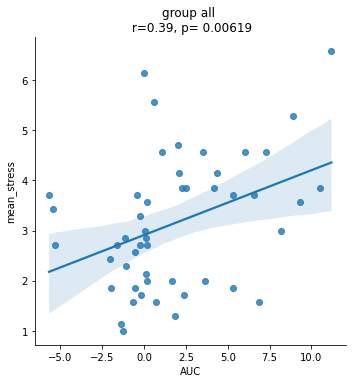

In [9]:
# testing which metric on self-rated-stress-level correlates best with AUC-cortisol

gr = 'all'
t = df#.xs(gr,0,'group')
var2 = 'mean_stress' #'min-max_diff'#'sd_stress'# 'auc_stress'#
sns.lmplot(data=df.reset_index() , x='AUC', y = var2) #, hue='group')
cor = pingouin.corr(t['AUC'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'group {gr} \n r={r_}, p= {p}')

In [10]:
# save
df.head()

,,q_stress_1,q_stress_2,q_stress_3,q_stress_4,q_stress_5,q_stress_6,q_stress_7,mean_stress,min-max_diff,sd_stress,auc_stress,AUC
subject,group,,,,,,,,,,,,
1,0,5,5,4,5,5,5,4,4.714286,1.0,1.308224,28.5,2.060
2,0,2,2,2,2,2,2,1,1.857143,1.0,0.434483,11.5,-0.505
3,1,5,6,5,5,6,2,3,4.571429,4.0,1.323090,28.0,3.530
4,1,4,5,6,5,5,4,3,4.571429,3.0,0.994315,28.5,1.055
5,0,1,2,2,1,3,1,1,1.571429,2.0,0.696200,10.0,-0.635


In [24]:
df['mean_stress'].to_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv')